In [1]:
# ============================================================
# 01 - DATA UNDERSTANDING & EXPLORATORY DATA ANALYSIS
# Projet : Prédiction de la Compatibilité Romantique
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Configuration d'affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("Bibliothèques chargées avec succès.")

Bibliothèques chargées avec succès.


In [2]:
# Vérifier le répertoire courant

print("Répertoire courant :")
print(os.getcwd())

print("\nContenu du répertoire :")
print(os.listdir())

Répertoire courant :
c:\Users\PC\Documents\GitHub\DM_PROJECT\notebooks

Contenu du répertoire :
['02_preprocessing.ipynb', '03_logistic_regression.ipynb', '04_decision_tree.ipynb', '05_random_forest.ipynb', '06_xgboost.ipynb', '07_evaluation_tuning.ipynb', '─ 01_data_understanding_eda.ipynb']


In [3]:
# ============================================================
# Recherche des fichiers CSV dans data/raw
# ============================================================

data_folder = "../data/raw"

if os.path.exists(data_folder):
    csv_files = [
        file for file in os.listdir(data_folder)
        if file.lower().endswith(".csv")
    ]

    print("Fichiers CSV trouvés :")

    if len(csv_files) == 0:
        print("Aucun fichier CSV trouvé dans :", data_folder)
    else:
        for i, file in enumerate(csv_files, start=1):
            print(f"{i}. {file}")
else:
    print("Le dossier data/raw n'existe pas.")

Fichiers CSV trouvés :
1. cupid_algorithm_dataset.csv


In [4]:
# ============================================================
# Chargement du dataset
# ============================================================

if len(csv_files) == 0:
    raise FileNotFoundError(
        "Aucun fichier CSV trouvé dans data/raw. "
        "Placez le dataset dans data/raw puis relancez cette cellule."
    )

if len(csv_files) > 1:
    print("Plusieurs fichiers CSV ont été trouvés :")
    for i, file in enumerate(csv_files, start=1):
        print(f"{i}. {file}")
    print("\nSélectionnez ensuite le fichier souhaité dans la variable DATASET_FILE.")
    
    DATASET_FILE = csv_files[0]
else:
    DATASET_FILE = csv_files[0]

DATASET_PATH = os.path.join(data_folder, DATASET_FILE)

df = pd.read_csv(DATASET_PATH)

print("Dataset chargé avec succès.")
print("Fichier :", DATASET_FILE)
print("Chemin :", DATASET_PATH)

Dataset chargé avec succès.
Fichier : cupid_algorithm_dataset.csv
Chemin : ../data/raw\cupid_algorithm_dataset.csv


In [5]:
# ============================================================
# Première inspection du dataset
# ============================================================

print("Dimensions du dataset :")
print(f"Nombre de lignes    : {df.shape[0]:,}")
print(f"Nombre de colonnes  : {df.shape[1]:,}")

Dimensions du dataset :
Nombre de lignes    : 100,000
Nombre de colonnes  : 30


In [6]:
# ============================================================
# Aperçu des données
# ============================================================

df.head(10)

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,a_love_language,a_emotional_expressiveness,b_age,b_education,b_location,b_career_field,b_career_ambition,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
0,1,46,3,Suburban,Healthcare,0.23,0.67,0.78,0.32,0.49,0.02,0.38,Receiving Gifts,0.59,20,3,Urban,Law,0.77,0.35,0.61,0.67,0.50,0.20,0.19,Quality Time,0.73,43.5,0,60
1,2,32,2,Suburban,Tech,0.58,0.78,0.70,0.51,0.71,0.43,0.72,Quality Time,0.73,38,1,Urban,Law,0.44,0.71,0.31,0.20,0.57,0.45,0.56,Physical Touch,0.84,60.4,0,59
2,3,25,4,Rural,Marketing,0.59,0.33,0.87,0.64,0.82,0.50,0.57,Acts of Service,0.69,46,2,Rural,Finance,0.61,0.28,0.30,0.49,0.43,0.84,0.74,Physical Touch,0.48,74.3,1,84
3,4,38,4,Suburban,Finance,0.54,0.34,0.28,0.72,0.81,0.43,0.60,Physical Touch,0.47,20,2,Urban,Science,0.39,0.47,0.35,0.46,0.21,0.80,0.35,Receiving Gifts,0.41,58.0,0,70
4,5,36,2,Rural,Entrepreneurship,0.56,0.35,0.62,0.27,0.73,0.32,0.63,Acts of Service,0.44,22,3,Urban,Creative Arts,0.63,0.44,0.66,0.45,0.43,0.86,0.36,Acts of Service,0.50,69.8,1,68
5,6,40,3,Urban,Science,0.75,0.45,0.40,0.71,0.54,0.26,0.24,Words of Affirmation,0.77,41,2,Suburban,Education,0.68,0.56,0.12,0.36,0.04,0.14,1.00,Receiving Gifts,0.83,67.2,1,64
6,7,28,1,Suburban,Tech,0.36,0.47,0.84,0.56,0.49,0.61,0.91,Quality Time,0.76,26,3,Rural,Science,0.58,0.61,0.26,0.26,0.49,0.36,0.43,Acts of Service,0.43,66.0,1,119
7,8,28,1,Suburban,Engineering,0.00,0.28,0.33,0.95,0.76,0.18,0.15,Quality Time,0.47,21,3,Urban,Marketing,0.62,0.58,0.73,0.40,0.42,0.62,0.71,Acts of Service,0.75,43.8,0,60
8,9,41,4,Urban,Entrepreneurship,0.52,0.69,0.50,0.25,0.34,0.15,0.59,Words of Affirmation,0.33,38,3,Rural,Finance,0.80,0.65,0.58,0.32,0.50,0.51,0.60,Words of Affirmation,0.86,72.9,1,69
9,10,53,5,Rural,Law,0.75,0.65,0.61,0.49,0.28,0.41,0.51,Words of Affirmation,0.71,36,4,Urban,Law,0.42,0.56,0.61,0.43,0.63,0.37,0.95,Physical Touch,0.32,60.9,0,85


In [8]:
df.tail()

,pair_id,a_age,a_education,a_location,a_career_field,a_career_ambition,a_openness,a_extraversion,a_agreeableness,a_conscientiousness,a_chronotype,a_spontaneity,a_love_language,a_emotional_expressiveness,b_age,b_education,b_location,b_career_field,b_career_ambition,b_openness,b_extraversion,b_agreeableness,b_conscientiousness,b_chronotype,b_spontaneity,b_love_language,b_emotional_expressiveness,compatibility_score,compatible,relationship_longevity_months
99995,99996,54,2,Urban,Healthcare,0.55,0.52,0.44,0.31,0.54,0.26,0.84,Acts of Service,0.65,52,3,Urban,Healthcare,0.48,0.63,0.07,0.12,0.21,0.90,0.54,Physical Touch,0.46,69.3,1,89
99996,99997,44,4,Suburban,Finance,0.77,0.58,0.42,0.20,0.34,0.62,0.84,Quality Time,0.44,46,2,Suburban,Entrepreneurship,0.33,0.86,0.99,0.62,0.84,0.41,0.81,Physical Touch,0.83,48.8,0,53
99997,99998,40,3,Urban,Marketing,0.41,0.60,0.76,0.26,0.28,0.95,0.94,Words of Affirmation,0.47,41,3,Urban,Entrepreneurship,0.34,0.19,0.67,0.63,0.56,0.34,0.39,Quality Time,0.43,60.4,0,69
99998,99999,43,2,Urban,Engineering,0.42,0.20,0.36,0.19,0.11,0.84,0.76,Physical Touch,0.51,53,2,Urban,Engineering,0.27,0.14,0.08,0.68,0.45,0.12,0.19,Acts of Service,0.24,53.4,0,64
99999,100000,22,4,Suburban,Education,0.43,0.80,0.33,0.25,0.40,0.29,0.69,Receiving Gifts,0.45,32,1,Urban,Engineering,0.35,0.45,0.42,0.75,0.46,0.46,0.64,Receiving Gifts,0.58,62.3,0,82


In [9]:
# ============================================================
# Informations générales
# ============================================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   pair_id                        100000 non-null  int64  
 1   a_age                          100000 non-null  int64  
 2   a_education                    100000 non-null  int64  
 3   a_location                     100000 non-null  str    
 4   a_career_field                 100000 non-null  str    
 5   a_career_ambition              100000 non-null  float64
 6   a_openness                     100000 non-null  float64
 7   a_extraversion                 100000 non-null  float64
 8   a_agreeableness                100000 non-null  float64
 9   a_conscientiousness            100000 non-null  float64
 10  a_chronotype                   100000 non-null  float64
 11  a_spontaneity                  100000 non-null  float64
 12  a_love_language                100000 non-

In [11]:
# ============================================================
# Liste des variables
# ============================================================

print("Nombre total de variables :", len(df.columns))
print("\nVariables :\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:3}. {column}")

Nombre total de variables : 30

Variables :

  1. pair_id
  2. a_age
  3. a_education
  4. a_location
  5. a_career_field
  6. a_career_ambition
  7. a_openness
  8. a_extraversion
  9. a_agreeableness
 10. a_conscientiousness
 11. a_chronotype
 12. a_spontaneity
 13. a_love_language
 14. a_emotional_expressiveness
 15. b_age
 16. b_education
 17. b_location
 18. b_career_field
 19. b_career_ambition
 20. b_openness
 21. b_extraversion
 22. b_agreeableness
 23. b_conscientiousness
 24. b_chronotype
 25. b_spontaneity
 26. b_love_language
 27. b_emotional_expressiveness
 28. compatibility_score
 29. compatible
 30. relationship_longevity_months


In [12]:
# ============================================================
# Types des variables
# ============================================================

types_df = pd.DataFrame({
    "Variable": df.columns,
    "Type": df.dtypes.astype(str).values
})

types_df

,Variable,Type
0,pair_id,int64
1,a_age,int64
2,a_education,int64
3,a_location,str
4,a_career_field,str
5,a_career_ambition,float64
6,a_openness,float64
7,a_extraversion,float64
8,a_agreeableness,float64
9,a_conscientiousness,float64


In [14]:
# ============================================================
# Variables numériques et catégorielles
# ============================================================

numeric_columns = df.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Variables numériques :")
print(numeric_columns)

print("\n" + "=" * 60)

print("Variables catégorielles :")
print(categorical_columns)

print("\nNombre de variables numériques :", len(numeric_columns))
print("Nombre de variables catégorielles :", len(categorical_columns))

Variables numériques :
['pair_id', 'a_age', 'a_education', 'a_career_ambition', 'a_openness', 'a_extraversion', 'a_agreeableness', 'a_conscientiousness', 'a_chronotype', 'a_spontaneity', 'a_emotional_expressiveness', 'b_age', 'b_education', 'b_career_ambition', 'b_openness', 'b_extraversion', 'b_agreeableness', 'b_conscientiousness', 'b_chronotype', 'b_spontaneity', 'b_emotional_expressiveness', 'compatibility_score', 'compatible', 'relationship_longevity_months']

Variables catégorielles :
['a_location', 'a_career_field', 'a_love_language', 'b_location', 'b_career_field', 'b_love_language']

Nombre de variables numériques : 24
Nombre de variables catégorielles : 6


In [16]:
# ============================================================
# Analyse des valeurs manquantes
# ============================================================

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_df = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": missing_count.values,
    "Missing_Percentage": missing_percentage.values
})

missing_df = missing_df.sort_values(
    by="Missing_Count",
    ascending=False
)

missing_df

,Variable,Missing_Count,Missing_Percentage
0,pair_id,0,0.0
1,a_age,0,0.0
2,a_education,0,0.0
3,a_location,0,0.0
4,a_career_field,0,0.0
5,a_career_ambition,0,0.0
6,a_openness,0,0.0
7,a_extraversion,0,0.0
8,a_agreeableness,0,0.0
9,a_conscientiousness,0,0.0


In [17]:
# ============================================================
# Variables avec valeurs manquantes
# ============================================================

missing_only = missing_df[
    missing_df["Missing_Count"] > 0
]

if missing_only.empty:
    print("Aucune valeur manquante détectée.")
else:
    print("Variables contenant des valeurs manquantes :")
    display(missing_only)

Aucune valeur manquante détectée.


In [18]:
# ============================================================
# Analyse des doublons
# ============================================================

duplicate_count = df.duplicated().sum()

print("Nombre de lignes dupliquées :", duplicate_count)

if duplicate_count > 0:
    print(
        f"Pourcentage de doublons : "
        f"{duplicate_count / len(df) * 100:.2f}%"
    )

Nombre de lignes dupliquées : 0


In [19]:
# ============================================================
# Statistiques descriptives - variables numériques
# ============================================================

if len(numeric_columns) > 0:
    display(df[numeric_columns].describe().T)
else:
    print("Aucune variable numérique détectée.")


,count,mean,std,min,25%,50%,75%,max
pair_id,100000.0,50000.500000,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
a_age,100000.0,36.558140,10.951788,18.0,27.00,37.0,46.00,55.0
a_education,100000.0,2.951980,1.117733,1.0,2.00,3.0,4.00,5.0
a_career_ambition,100000.0,0.496463,0.174898,0.0,0.37,0.5,0.62,1.0
a_openness,100000.0,0.499959,0.223607,0.0,0.33,0.5,0.67,1.0
a_extraversion,100000.0,0.500131,0.224783,0.0,0.33,0.5,0.67,1.0
a_agreeableness,100000.0,0.501397,0.223860,0.0,0.33,0.5,0.68,1.0
a_conscientiousness,100000.0,0.498643,0.223444,0.0,0.32,0.5,0.67,1.0
a_chronotype,100000.0,0.499697,0.224779,0.0,0.33,0.5,0.67,1.0
a_spontaneity,100000.0,0.500012,0.226265,0.0,0.33,0.5,0.67,1.0


In [20]:
# ============================================================
# Statistiques - variables catégorielles
# ============================================================

if len(categorical_columns) > 0:
    display(df[categorical_columns].describe().T)
else:
    print("Aucune variable catégorielle détectée.")

,count,unique,top,freq
a_location,100000,3,Urban,49832
a_career_field,100000,10,Finance,10169
a_love_language,100000,5,Words of Affirmation,20160
b_location,100000,3,Urban,49837
b_career_field,100000,10,Marketing,10124
b_love_language,100000,5,Receiving Gifts,20276


In [21]:
# ============================================================
# Nombre de valeurs uniques par variable
# ============================================================

unique_df = pd.DataFrame({
    "Variable": df.columns,
    "Unique_Values": [
        df[column].nunique(dropna=False)
        for column in df.columns
    ]
})

unique_df = unique_df.sort_values(
    by="Unique_Values",
    ascending=False
)

unique_df

,Variable,Unique_Values
0,pair_id,100000
27,compatibility_score,746
29,relationship_longevity_months,121
8,a_agreeableness,101
9,a_conscientiousness,101
5,a_career_ambition,101
10,a_chronotype,101
11,a_spontaneity,101
13,a_emotional_expressiveness,101
23,b_chronotype,101


In [22]:
# ============================================================
# Nombre de valeurs uniques par variable
# ============================================================

unique_df = pd.DataFrame({
    "Variable": df.columns,
    "Unique_Values": [
        df[column].nunique(dropna=False)
        for column in df.columns
    ]
})

unique_df = unique_df.sort_values(
    by="Unique_Values",
    ascending=False
)

unique_df

,Variable,Unique_Values
0,pair_id,100000
27,compatibility_score,746
29,relationship_longevity_months,121
8,a_agreeableness,101
9,a_conscientiousness,101
5,a_career_ambition,101
10,a_chronotype,101
11,a_spontaneity,101
13,a_emotional_expressiveness,101
23,b_chronotype,101


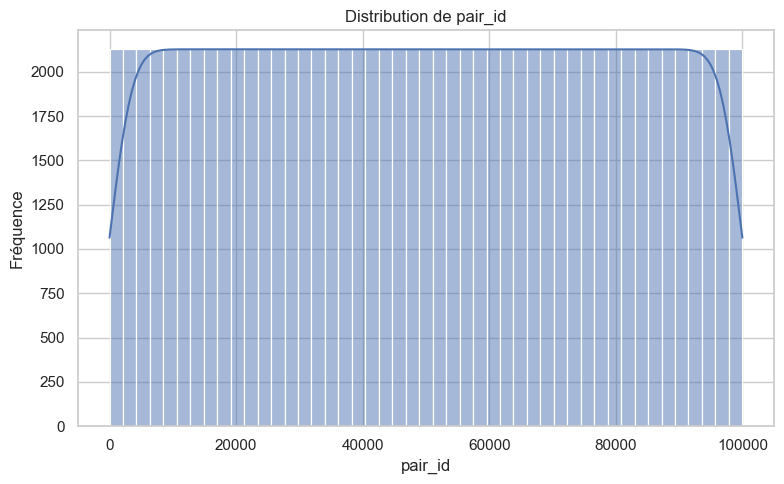

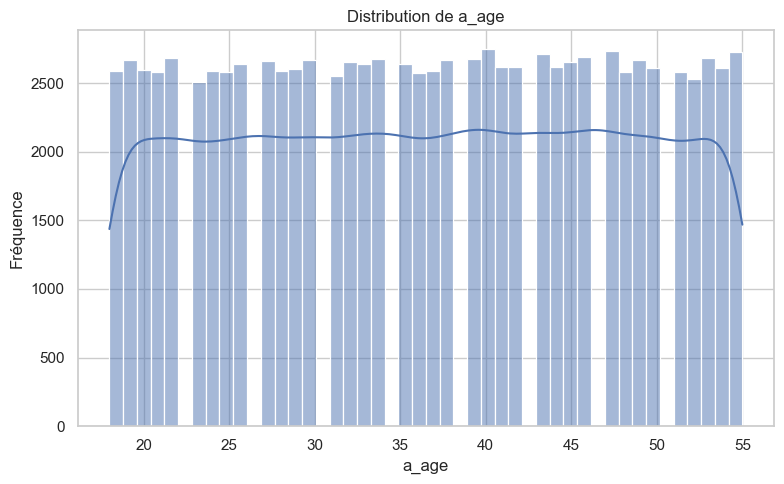

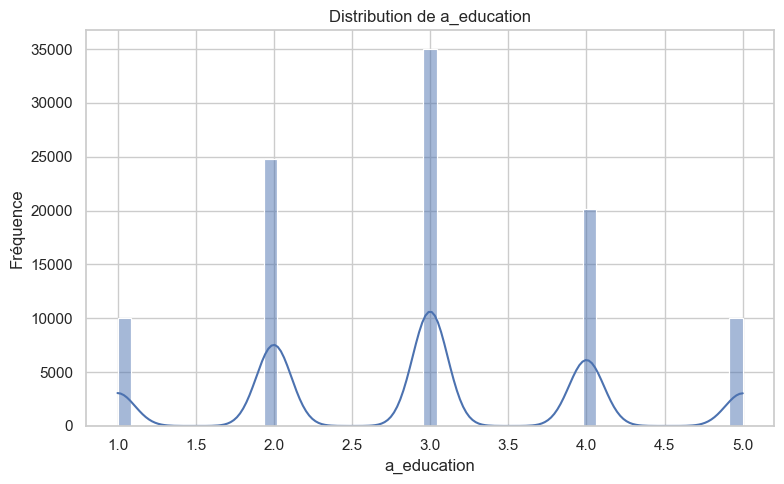

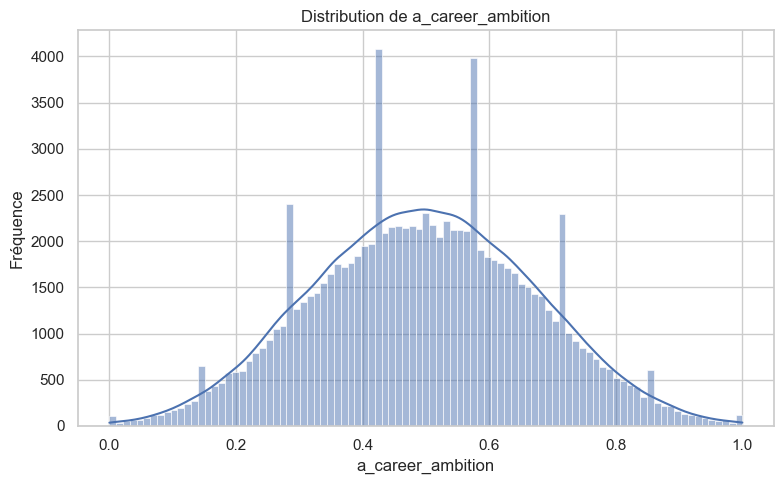

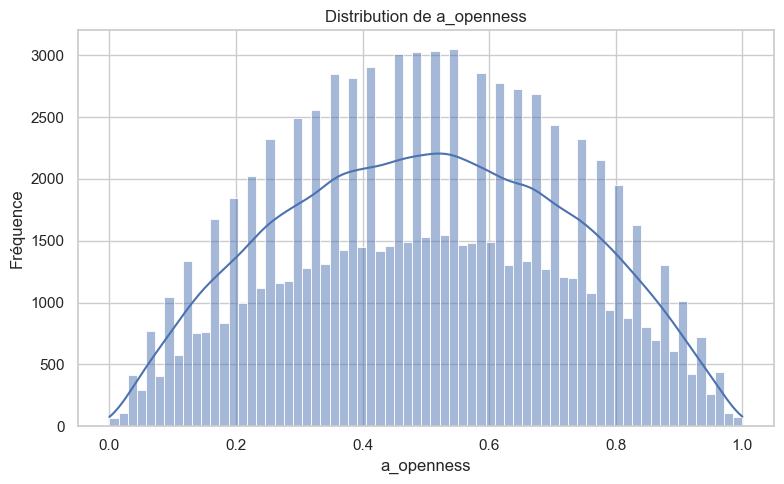

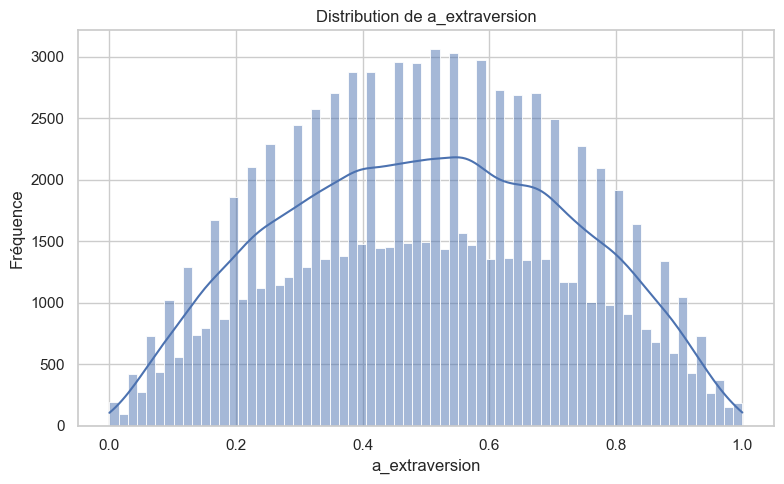

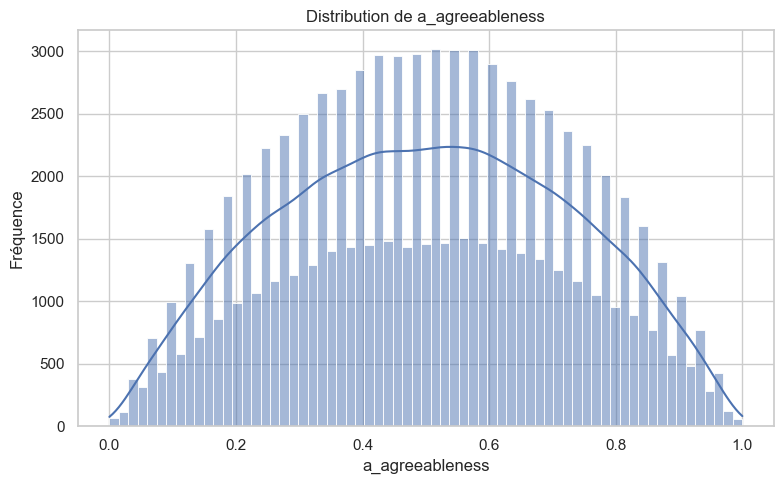

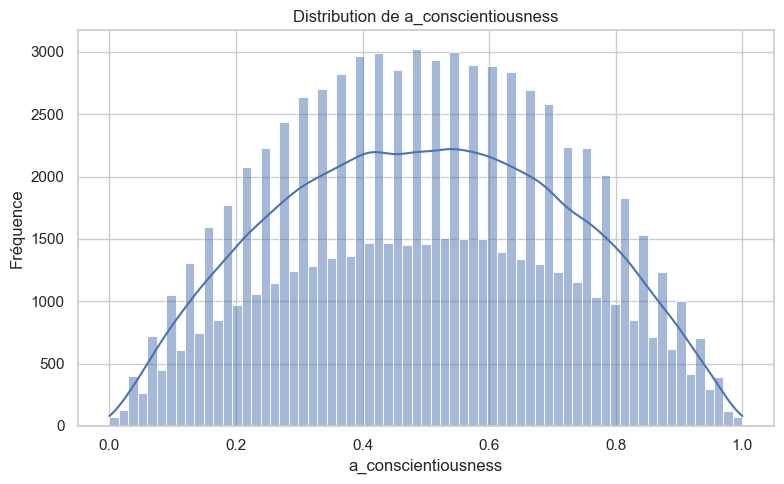

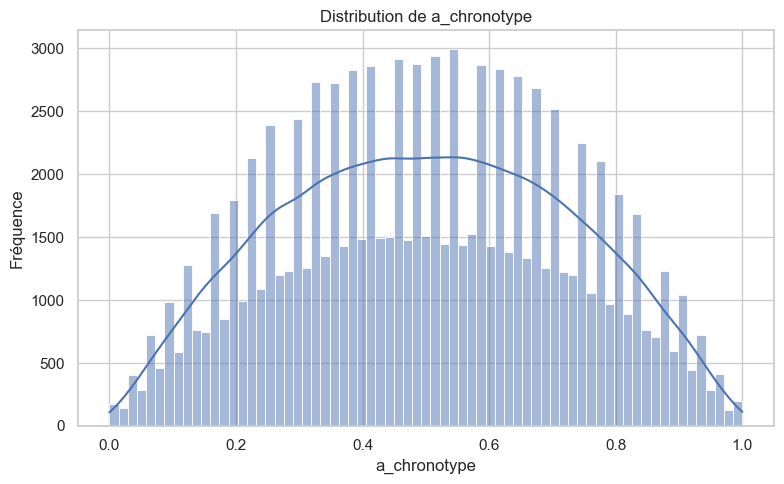

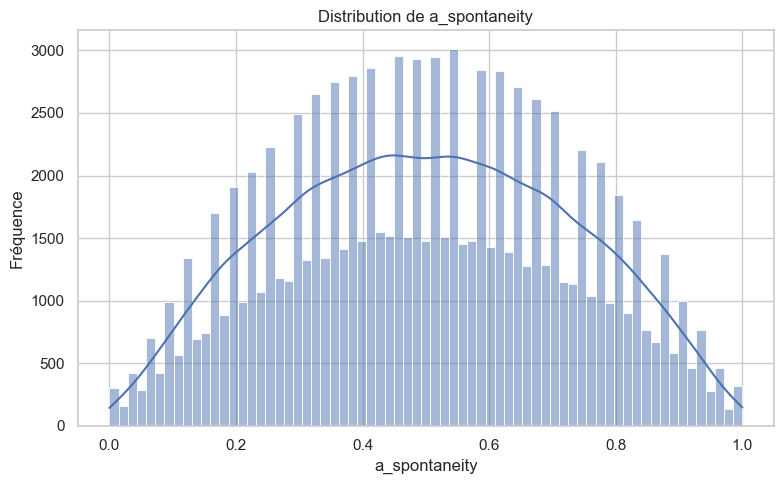

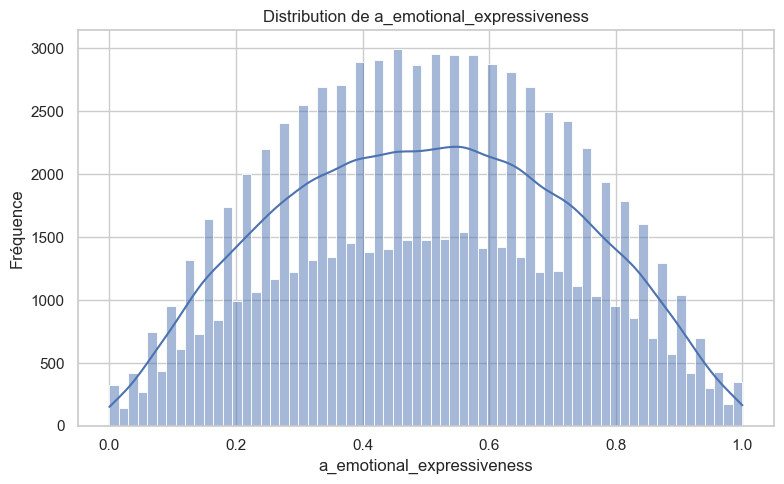

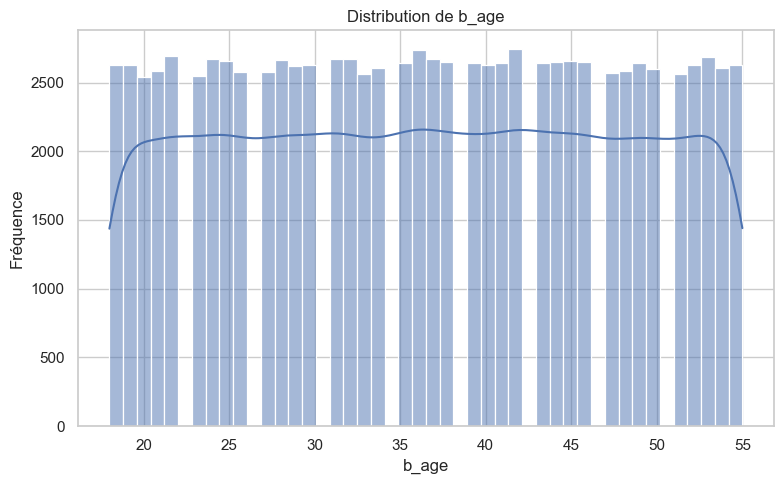

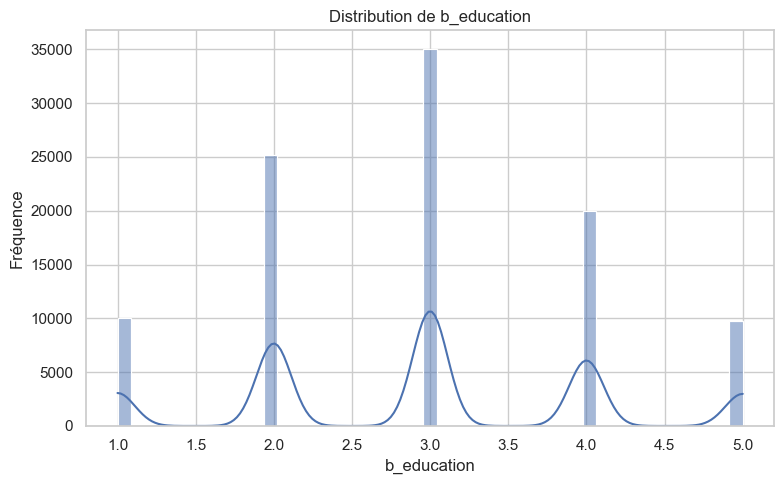

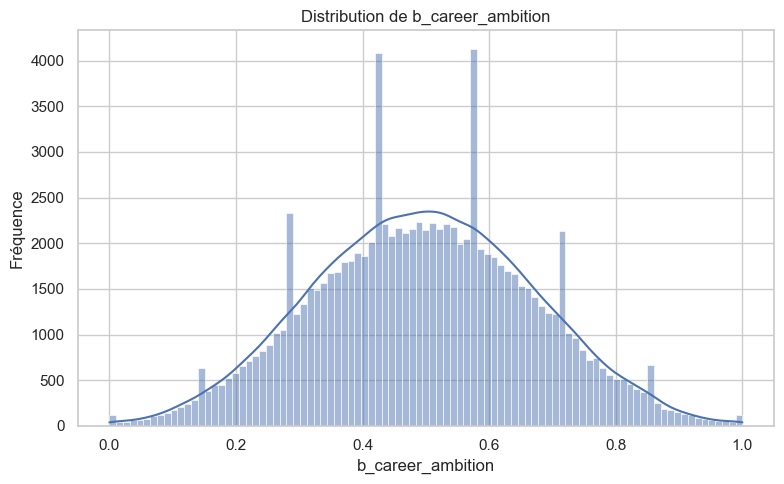

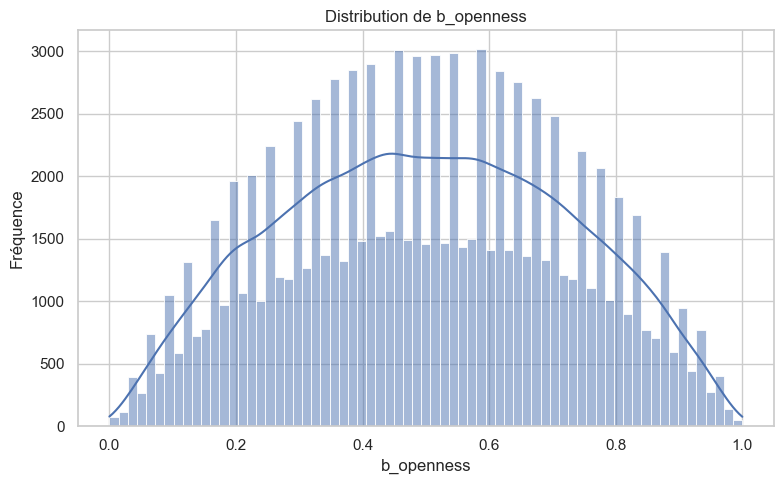

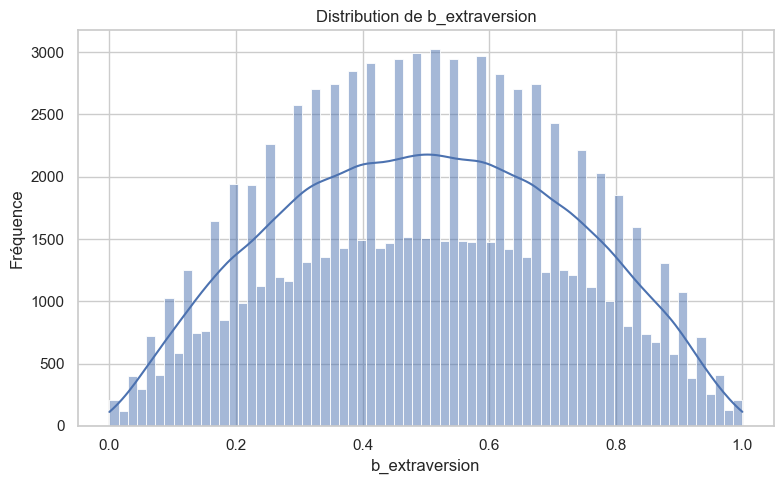

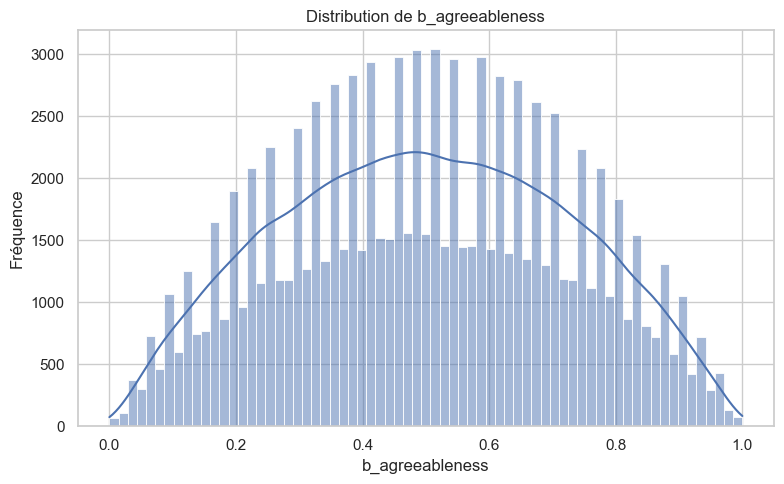

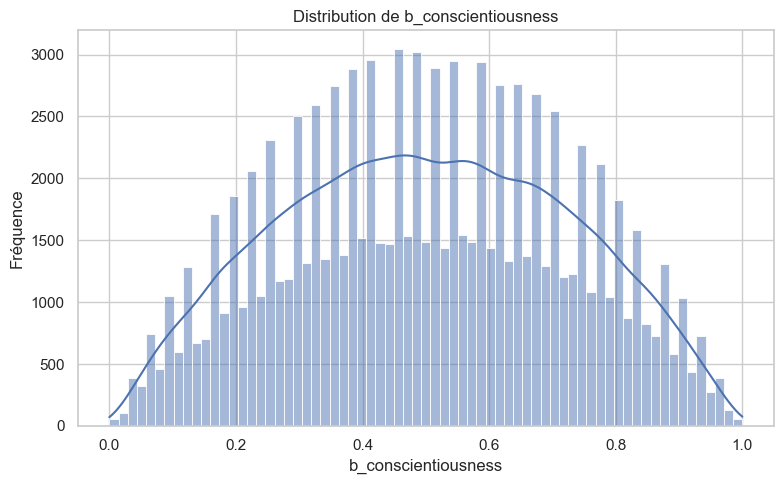

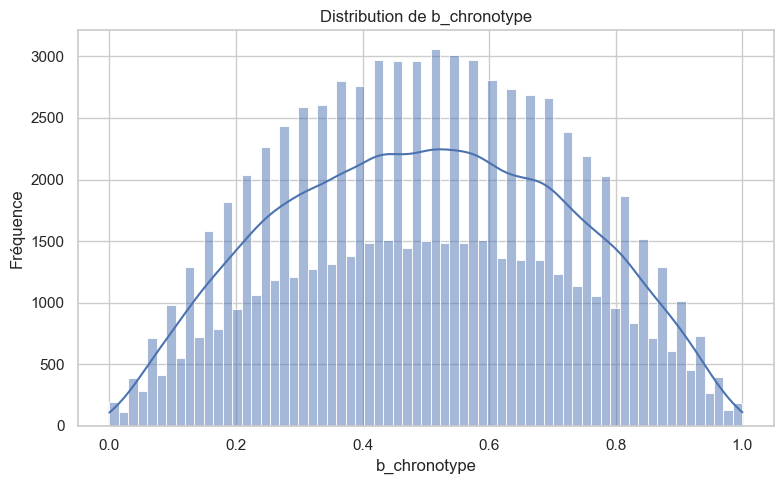

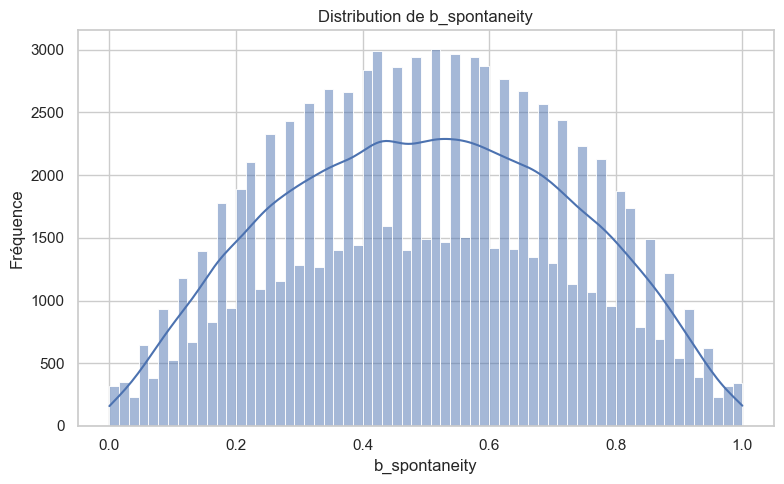

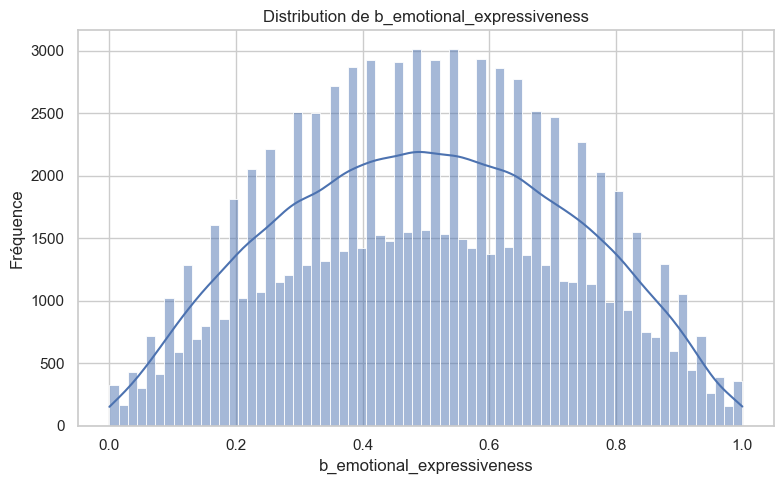

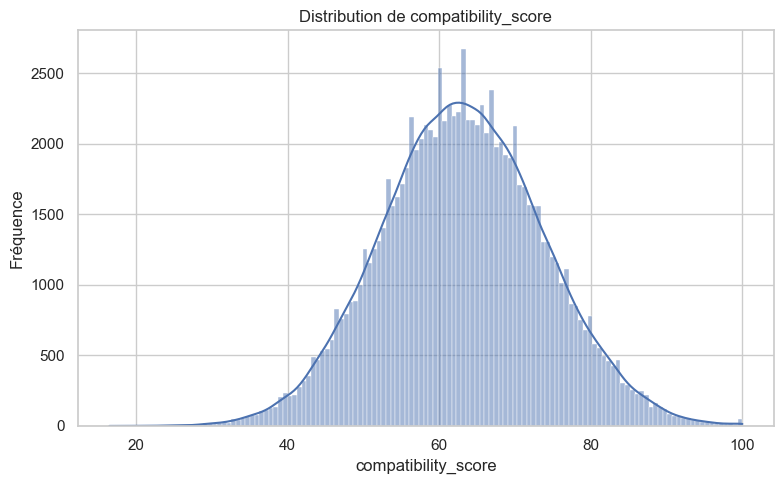

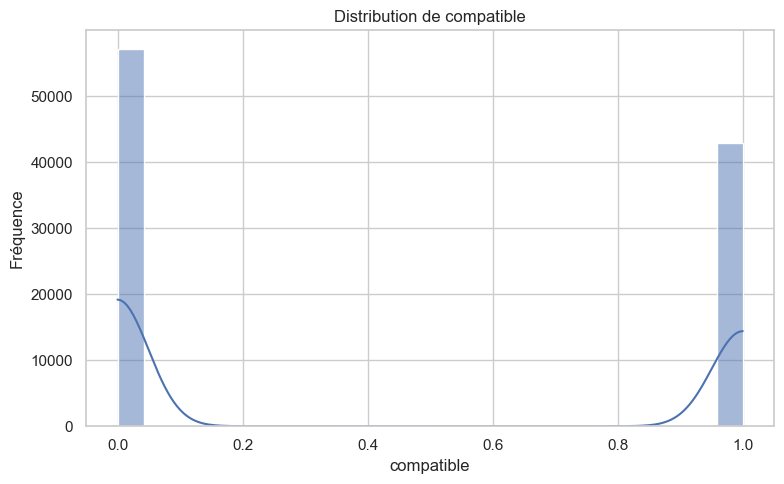

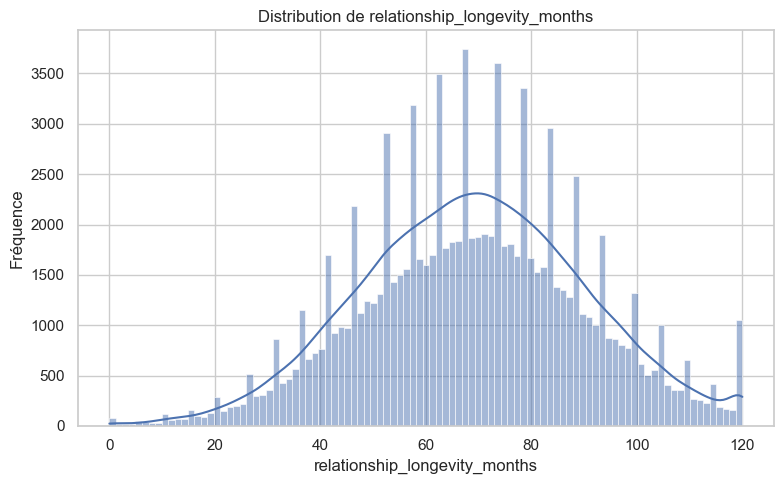

In [23]:
# ============================================================
# Distribution des variables numériques
# ============================================================

if len(numeric_columns) > 0:

    for column in numeric_columns:
        plt.figure(figsize=(8, 5))

        sns.histplot(
            data=df,
            x=column,
            kde=True
        )

        plt.title(f"Distribution de {column}")
        plt.xlabel(column)
        plt.ylabel("Fréquence")

        plt.tight_layout()
        plt.show()

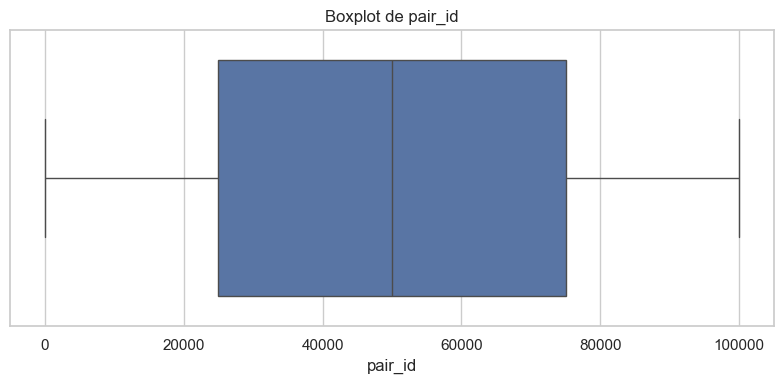

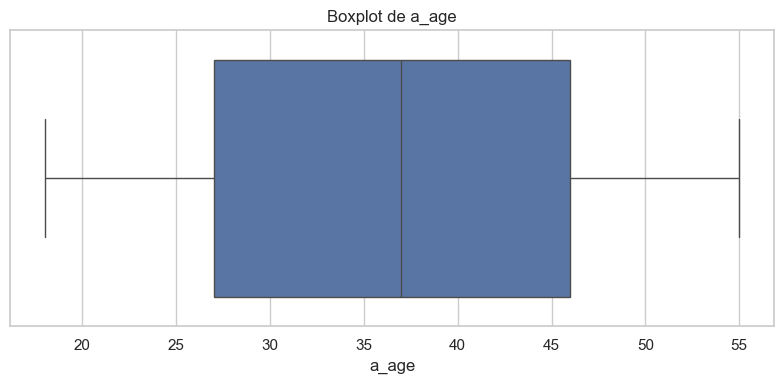

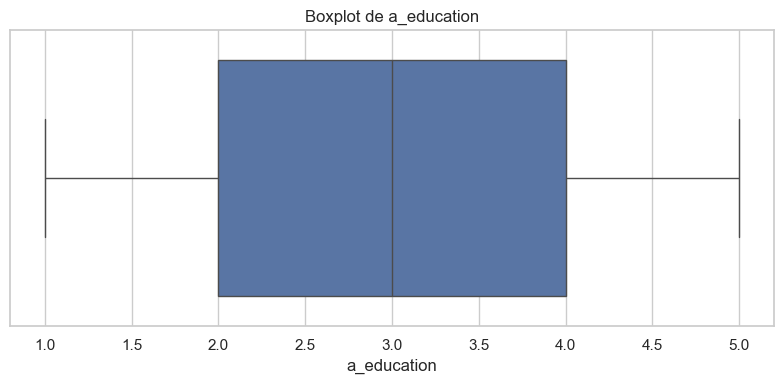

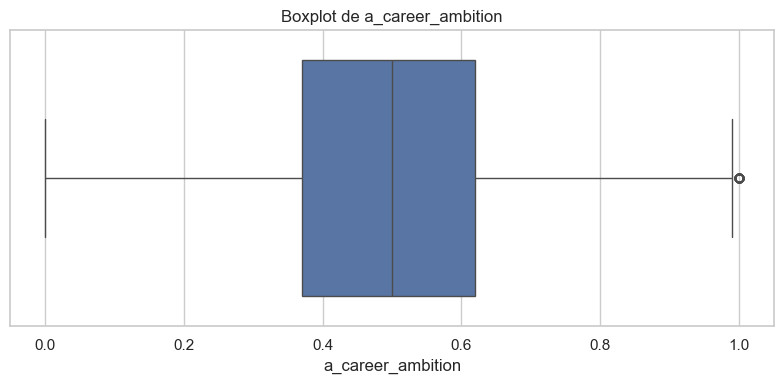

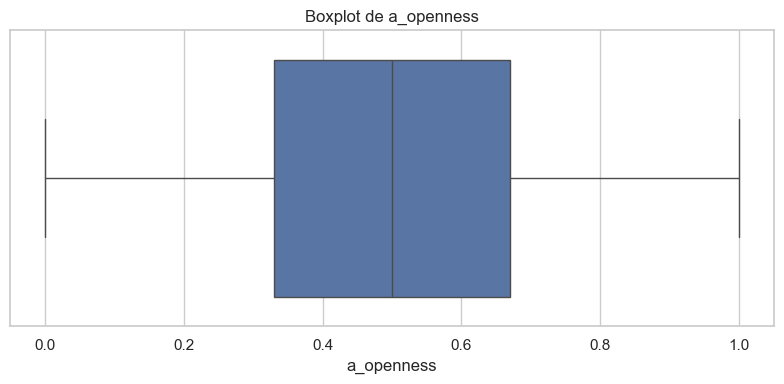

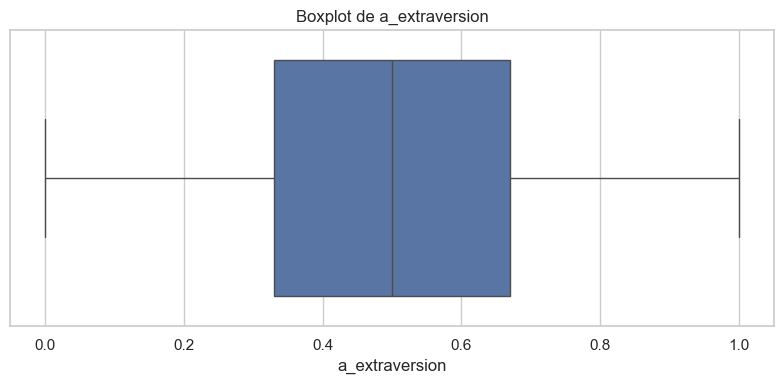

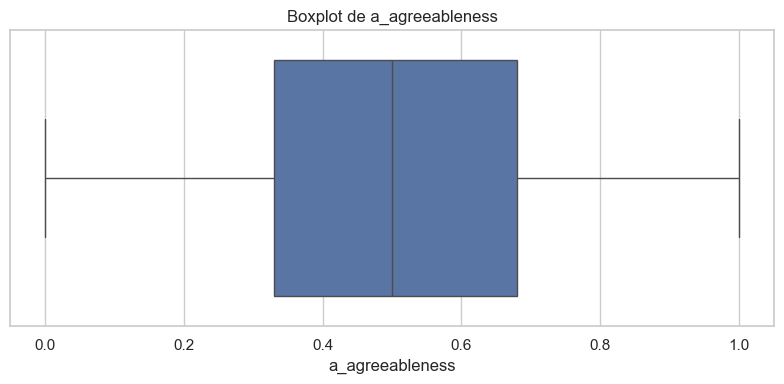

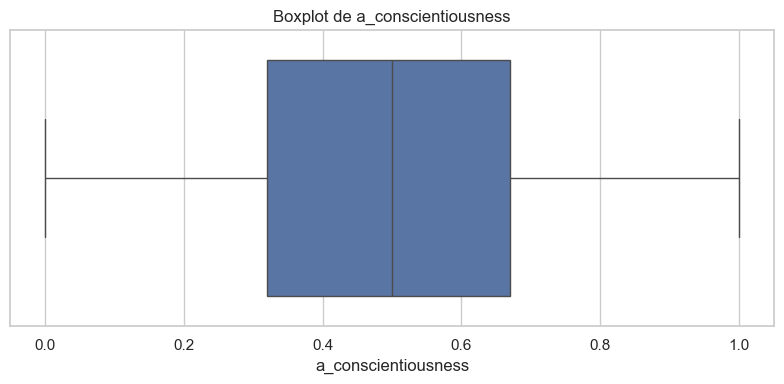

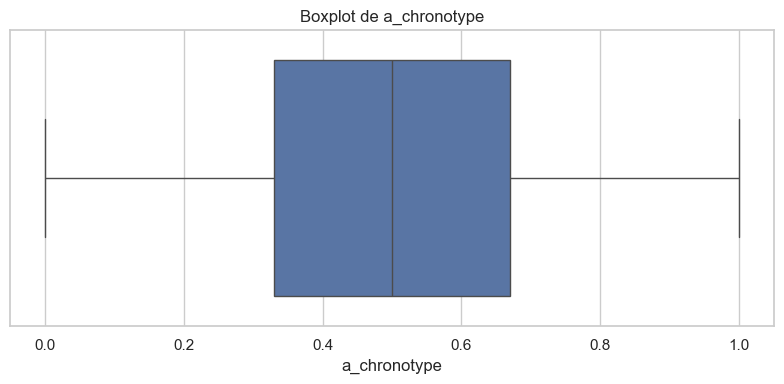

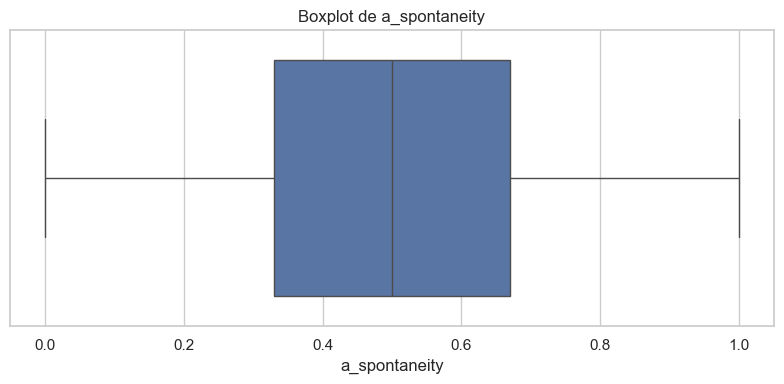

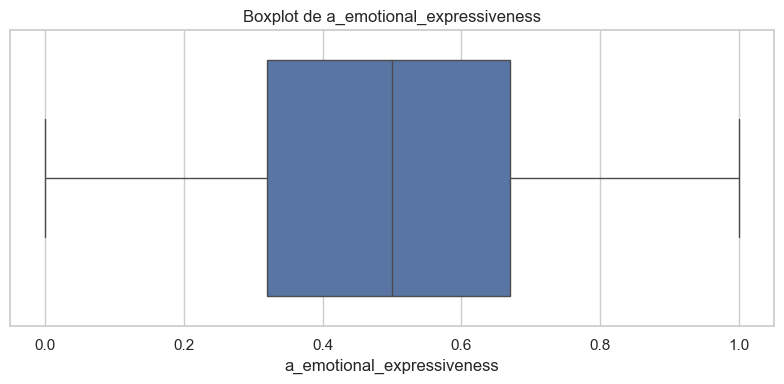

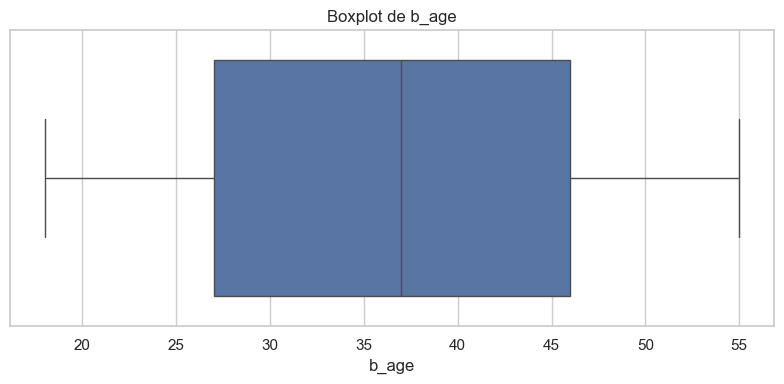

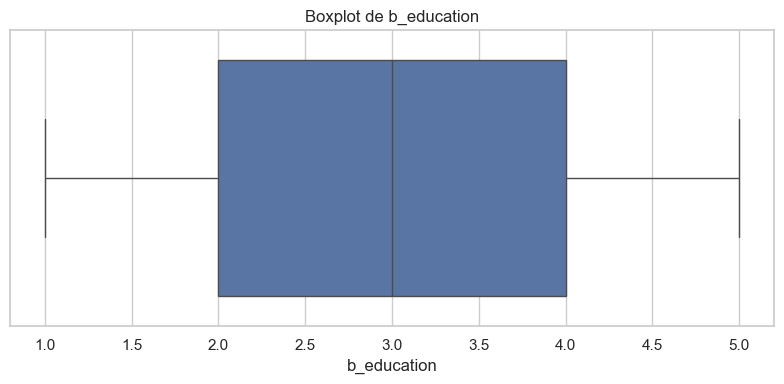

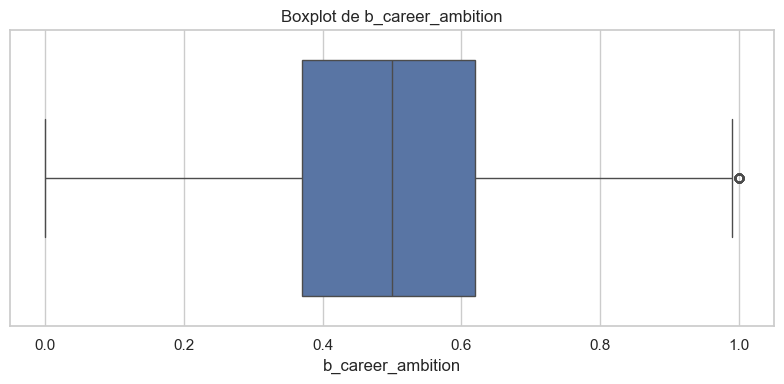

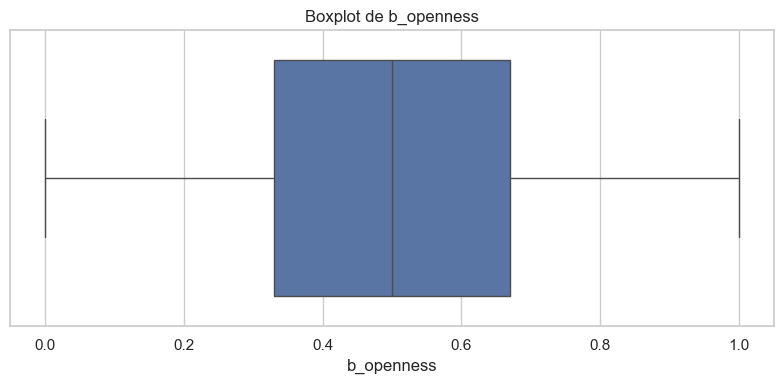

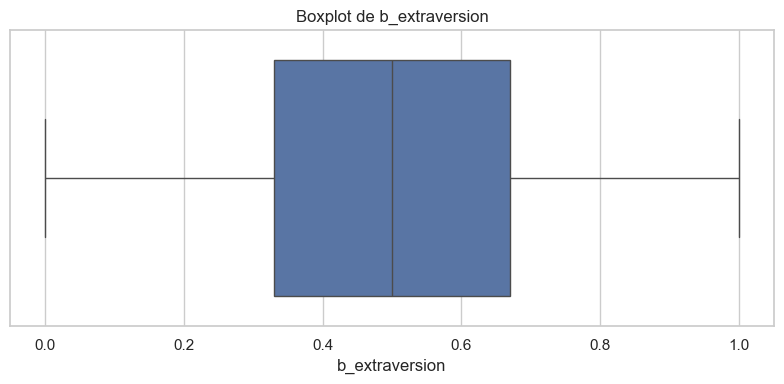

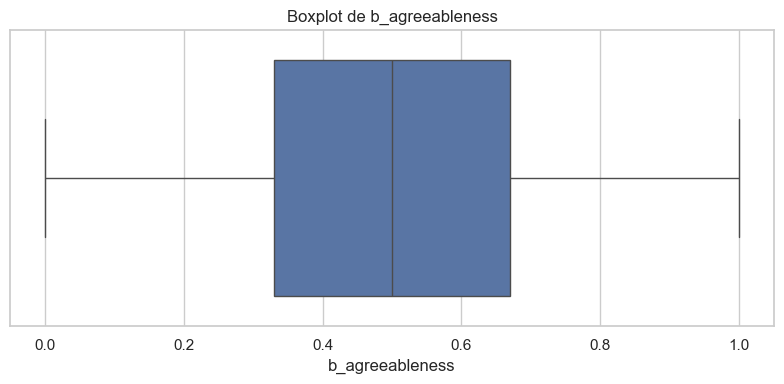

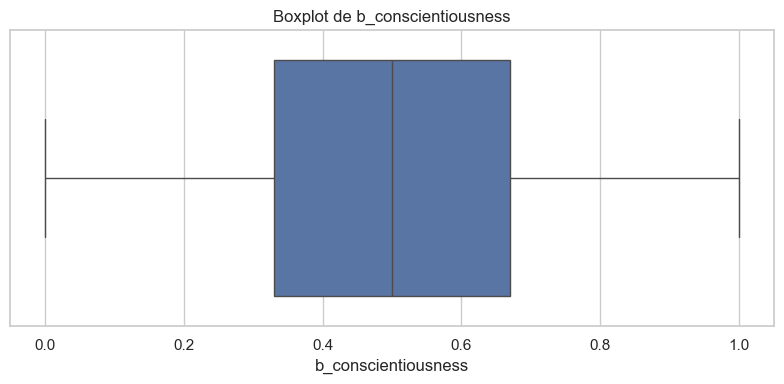

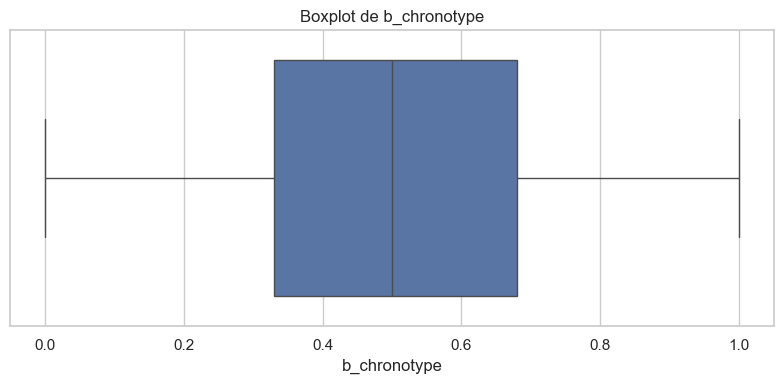

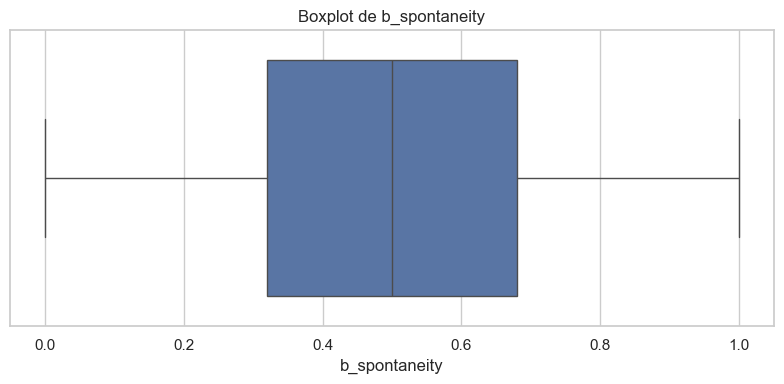

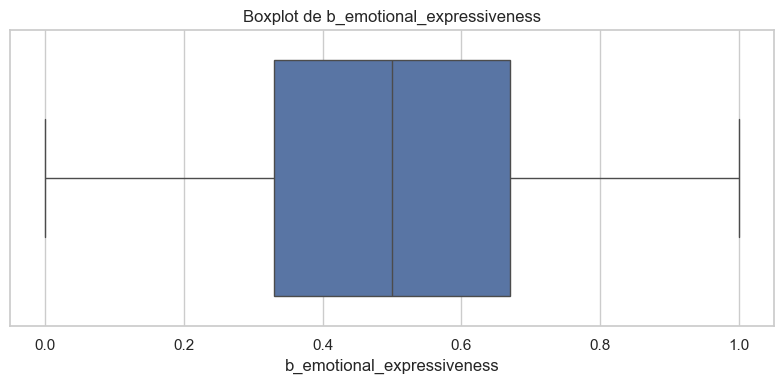

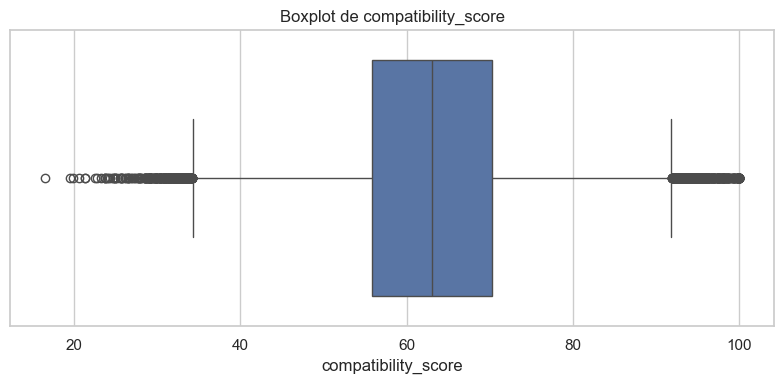

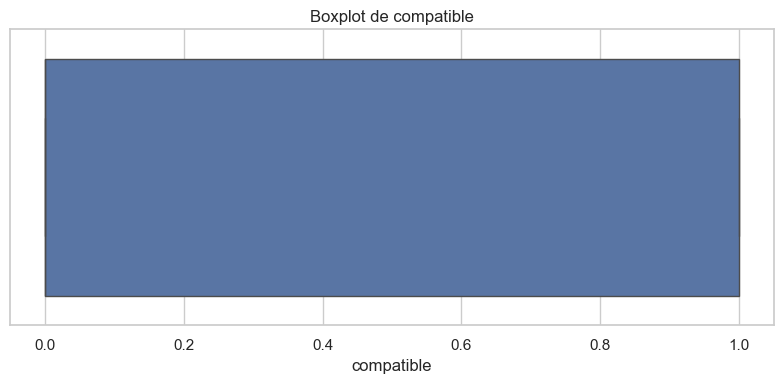

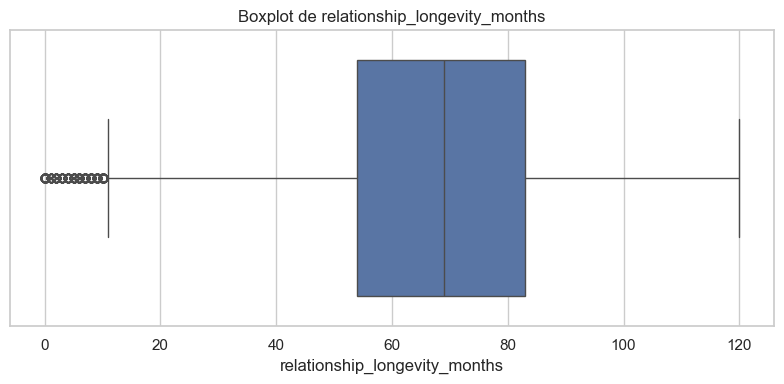

In [24]:
# ============================================================
# Boxplots des variables numériques
# ============================================================

if len(numeric_columns) > 0:

    for column in numeric_columns:
        plt.figure(figsize=(8, 4))

        sns.boxplot(
            data=df,
            x=column
        )

        plt.title(f"Boxplot de {column}")

        plt.tight_layout()
        plt.show()

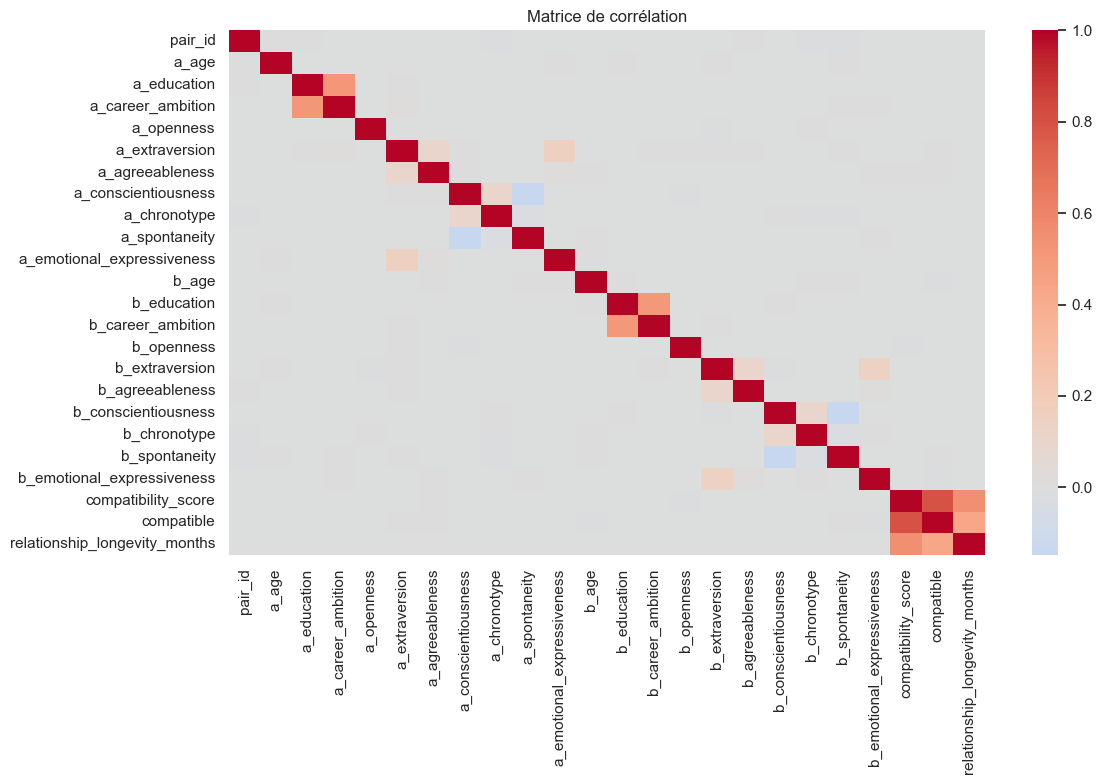

In [25]:
# ============================================================
# Matrice de corrélation
# ============================================================

if len(numeric_columns) >= 2:

    correlation_matrix = df[numeric_columns].corr()

    plt.figure(figsize=(12, 8))

    sns.heatmap(
        correlation_matrix,
        annot=False,
        cmap="coolwarm",
        center=0
    )

    plt.title("Matrice de corrélation")
    plt.tight_layout()
    plt.show()

else:
    print("Pas assez de variables numériques pour calculer une matrice de corrélation.")

In [26]:
# ============================================================
# Recherche de variables potentiellement identifiantes
# ============================================================

identifier_candidates = []

for column in df.columns:
    unique_ratio = df[column].nunique(dropna=False) / len(df)

    if unique_ratio >= 0.95:
        identifier_candidates.append(
            (column, df[column].nunique(dropna=False), unique_ratio)
        )

if identifier_candidates:
    print("Variables potentiellement identifiantes :\n")

    for column, unique_count, ratio in identifier_candidates:
        print(
            f"{column} -> "
            f"{unique_count:,} valeurs uniques "
            f"({ratio * 100:.2f}%)"
        )
else:
    print("Aucune variable potentiellement identifiante détectée.")

Variables potentiellement identifiantes :

pair_id -> 100,000 valeurs uniques (100.00%)


In [27]:
# ============================================================
# VARIABLES DISPONIBLES POUR IDENTIFIER LA CIBLE
# ============================================================

print("Toutes les variables disponibles :\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i:3}. {column}")

Toutes les variables disponibles :

  1. pair_id
  2. a_age
  3. a_education
  4. a_location
  5. a_career_field
  6. a_career_ambition
  7. a_openness
  8. a_extraversion
  9. a_agreeableness
 10. a_conscientiousness
 11. a_chronotype
 12. a_spontaneity
 13. a_love_language
 14. a_emotional_expressiveness
 15. b_age
 16. b_education
 17. b_location
 18. b_career_field
 19. b_career_ambition
 20. b_openness
 21. b_extraversion
 22. b_agreeableness
 23. b_conscientiousness
 24. b_chronotype
 25. b_spontaneity
 26. b_love_language
 27. b_emotional_expressiveness
 28. compatibility_score
 29. compatible
 30. relationship_longevity_months


In [28]:
# ============================================================
# Résumé automatique du dataset
# ============================================================

eda_summary = {
    "Nombre de lignes": df.shape[0],
    "Nombre de colonnes": df.shape[1],
    "Variables numériques": len(numeric_columns),
    "Variables catégorielles": len(categorical_columns),
    "Valeurs manquantes": int(df.isnull().sum().sum()),
    "Lignes dupliquées": int(df.duplicated().sum())
}

summary_df = pd.DataFrame(
    list(eda_summary.items()),
    columns=["Indicateur", "Valeur"]
)

summary_df

,Indicateur,Valeur
0,Nombre de lignes,100000
1,Nombre de colonnes,30
2,Variables numériques,24
3,Variables catégorielles,6
4,Valeurs manquantes,0
5,Lignes dupliquées,0


In [29]:
# ============================================================
# Sauvegarde des résultats EDA
# ============================================================

results_folder = "../results/tables"

os.makedirs(results_folder, exist_ok=True)

types_df.to_csv(
    os.path.join(results_folder, "variable_types.csv"),
    index=False
)

missing_df.to_csv(
    os.path.join(results_folder, "missing_values.csv"),
    index=False
)

unique_df.to_csv(
    os.path.join(results_folder, "unique_values.csv"),
    index=False
)

summary_df.to_csv(
    os.path.join(results_folder, "eda_summary.csv"),
    index=False
)

print("Résultats EDA sauvegardés dans :", results_folder)

Résultats EDA sauvegardés dans : ../results/tables
